### ECG Heartbeat Classification: Decision Tree vs Random Forest with PCA 
---

## Table of Contents

1. [Task 1 – Exploratory Data Analysis](#task1)
2. [Task 2 – Preprocessing & Feature Engineering → ABT](#task2)
3. [Task 3 – Pairwise Correlations](#task3)
4. [Task 4 – Principal Component Analysis](#task4)
5. [Task 5 – PC Correlations & Feature Selection](#task5)
6. [Task 6 – Dataset Partition](#task6)
7. [Task 7 – Decision Tree](#task7)
8. [Task 8 – Random Forest](#task8)
9. [Task 9 – F1 Comparison & Condorcet Jury Theorem](#task9)
10. [Task 10 – 10-Fold Cross Validation & Statistical Significance](#task10)


## Setup & Imports

In [2]:
import warnings, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              classification_report, f1_score,
                              roc_auc_score, roc_curve)
from sklearn.model_selection import (cross_val_score, StratifiedKFold,
                                     cross_validate)

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})
COLORS = ["#2196F3", "#E53935"]   # blue=Normal, red=Abnormal
SEED   = 42
print("Libraries loaded successfully.")


Libraries loaded successfully.


---
## Data Loading & Parsing

The CSV has **no column headings**. Each row stores a variable-length ECG amplitude sequence, and the **last non-null value** is the class label (1 = Normal, 0 = Abnormal). Standard `read_csv` into a 141-column frame leaves trailing NaNs for shorter sequences, so the label is extracted programmatically as the last non-null element per row.


In [4]:
RAW_PATH = r"C:\Users\anele\OneDrive\Documents\Masters\Coursework\Data_Science\Post-Block Assignment 2\ecg_curated.csv"
df_raw   = pd.read_csv(RAW_PATH, header=None)

y_raw_list    = []
features_list = []
for i in range(len(df_raw)):
    row = df_raw.iloc[i].dropna().values
    y_raw_list.append(int(row[-1]))
    features_list.append(row[:-1])

y_raw        = np.array(y_raw_list)
feat_lengths = np.array([len(f) for f in features_list])

print(f"Total instances : {len(y_raw)}")
print(f"Normal  (1): {np.sum(y_raw==1):4d} ({np.sum(y_raw==1)/len(y_raw)*100:.1f}%)")
print(f"Abnormal(0): {np.sum(y_raw==0):4d} ({np.sum(y_raw==0)/len(y_raw)*100:.1f}%)")
print(f"Sequence lengths: {dict(zip(*np.unique(feat_lengths, return_counts=True)))}")


Total instances : 4999
Normal  (1): 2920 (58.4%)
Abnormal(0): 2079 (41.6%)
Sequence lengths: {137: 302, 138: 1101, 139: 1000, 140: 2596}


---
<a id='task1'></a>
## Task 1 – Exploratory Data Analysis

### Background: Normal vs Abnormal ECG Heartbeats

A normal ECG heartbeat (sinus rhythm) shows a characteristic PQRST complex: a small P-wave (atrial depolarisation), a sharp QRS complex (ventricular depolarisation with a dominant R-peak), and a broader T-wave (ventricular repolarisation). The amplitude envelope is stereotyped and the R-peak occurs at a consistent relative position within the beat.

Abnormal heartbeats deviate from this template in several clinically meaningful ways:
- **Arrhythmias** (e.g., premature ventricular contractions) display exaggerated or inverted QRS morphology.
- **Ischaemic beats** may show ST-segment depression or elevation.
- **Bundle-branch blocks** widen and distort the QRS complex, splitting the R-peak.
- **Paced beats** show a pacing spike followed by a broad, low-amplitude QRS.

These morphological differences translate into observable differences in statistical features (amplitude range, trough timing, skewness, etc.) that motivate the feature engineering performed in Task 2.

### Dataset Observations


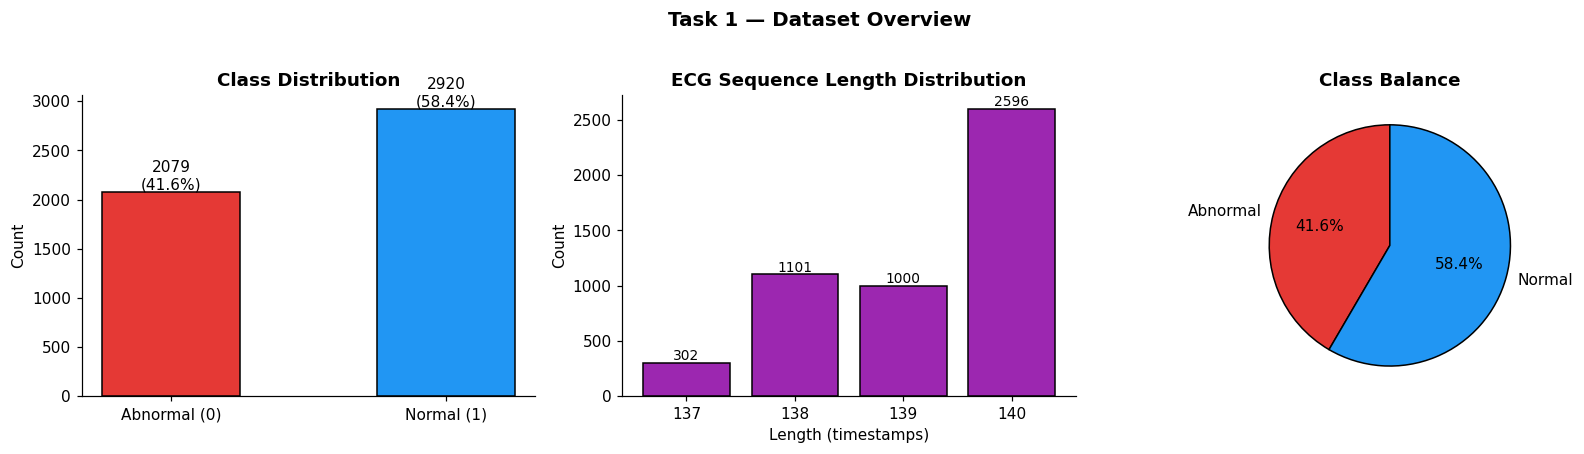


Key findings:
  • Mild class imbalance: Normal beats are 1.40x more frequent.
  • 4 distinct sequence lengths (137–140), caused by variable heartbeat capture windows.
  • 2596 of 4999 beats (51.9%) have the maximum length of 140.


In [7]:
# Class distribution
class_counts = pd.Series(y_raw).value_counts().sort_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Bar chart
bars = axes[0].bar(["Abnormal (0)","Normal (1)"],
                   [class_counts[0], class_counts[1]],
                   color=COLORS[::-1], edgecolor="k", width=0.5)
axes[0].bar_label(bars, labels=[f"{v}\n({v/len(y_raw)*100:.1f}%)"
                                 for v in [class_counts[0], class_counts[1]]], fontsize=10)
axes[0].set_title("Class Distribution", fontweight="bold"); axes[0].set_ylabel("Count")

# Sequence length distribution
u, c = np.unique(feat_lengths, return_counts=True)
axes[1].bar(u.astype(str), c, color="#9C27B0", edgecolor="k")
axes[1].bar_label(axes[1].containers[0], fontsize=9)
axes[1].set_title("ECG Sequence Length Distribution", fontweight="bold")
axes[1].set_xlabel("Length (timestamps)"); axes[1].set_ylabel("Count")

# Pie chart
axes[2].pie([class_counts[0], class_counts[1]],
            labels=["Abnormal","Normal"], colors=COLORS[::-1],
            autopct="%1.1f%%", startangle=90, wedgeprops=dict(edgecolor="k"))
axes[2].set_title("Class Balance", fontweight="bold")

plt.suptitle("Task 1 — Dataset Overview", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

print(f"\nKey findings:")
print(f"  • Mild class imbalance: Normal beats are {class_counts[1]/class_counts[0]:.2f}x more frequent.")
print(f"  • 4 distinct sequence lengths (137–140), caused by variable heartbeat capture windows.")
print(f"  • {np.sum(feat_lengths==140)} of {len(y_raw)} beats ({np.sum(feat_lengths==140)/len(y_raw)*100:.1f}%) have the maximum length of 140.")


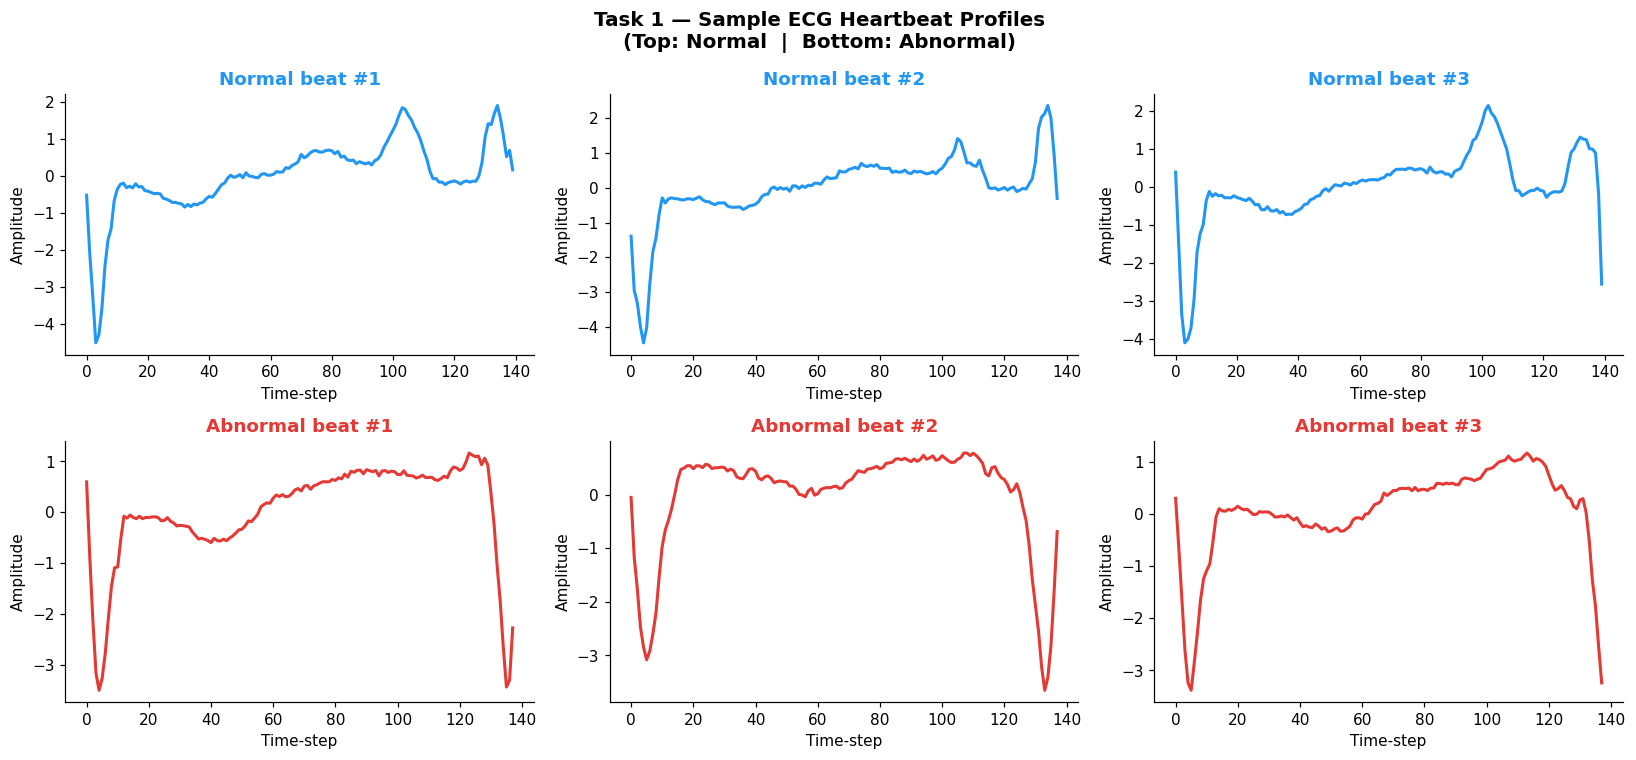

In [9]:
# Sample waveforms – visual comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
fig.suptitle("Task 1 — Sample ECG Heartbeat Profiles\n(Top: Normal  |  Bottom: Abnormal)",
             fontsize=13, fontweight="bold")
for i, ax in enumerate(axes[0]):
    idx = np.where(y_raw == 1)[0][i]
    ax.plot(features_list[idx], color=COLORS[0], lw=2)
    ax.set_title(f"Normal beat #{i+1}", color=COLORS[0], fontweight="bold")
    ax.set_xlabel("Time-step"); ax.set_ylabel("Amplitude")
for i, ax in enumerate(axes[1]):
    idx = np.where(y_raw == 0)[0][i]
    ax.plot(features_list[idx], color=COLORS[1], lw=2)
    ax.set_title(f"Abnormal beat #{i+1}", color=COLORS[1], fontweight="bold")
    ax.set_xlabel("Time-step"); ax.set_ylabel("Amplitude")
plt.tight_layout(); plt.show()


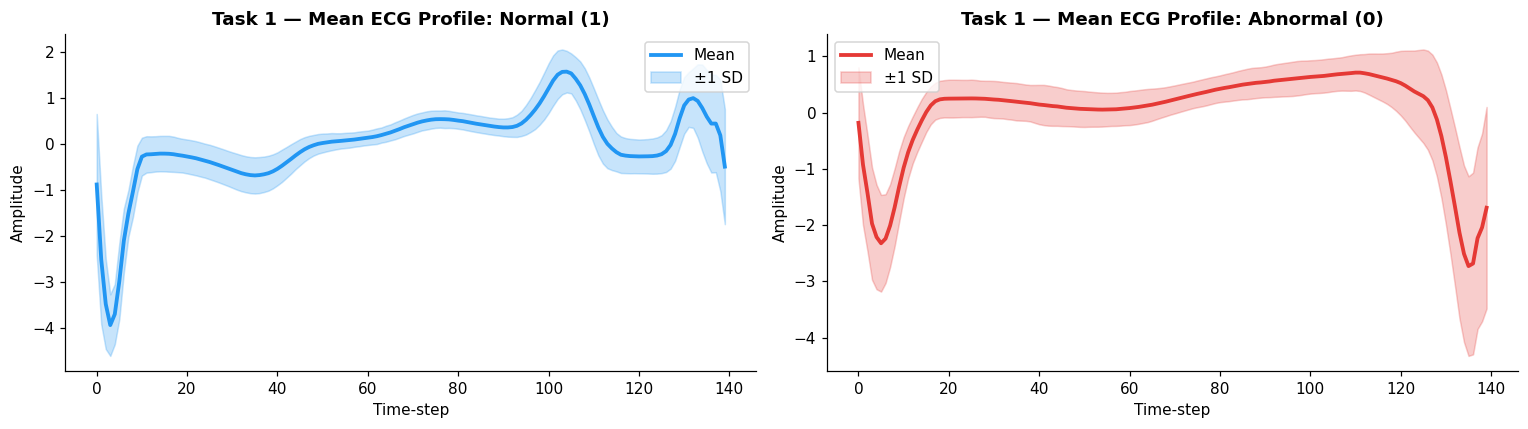

In [11]:
# Mean ± SD waveforms per class
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, cls, label, col in zip(axes, [1, 0], ["Normal (1)", "Abnormal (0)"], COLORS):
    subset = np.array([
        np.pad(f, (0, 140-len(f)), mode="edge") if len(f)<140 else f[:140]
        for f, y in zip(features_list, y_raw) if y == cls
    ])
    mean_w = subset.mean(axis=0); std_w = subset.std(axis=0)
    ax.plot(mean_w, color=col, lw=2.5, label="Mean")
    ax.fill_between(range(140), mean_w-std_w, mean_w+std_w, alpha=0.25, color=col, label="±1 SD")
    ax.set_title(f"Task 1 — Mean ECG Profile: {label}", fontweight="bold")
    ax.set_xlabel("Time-step"); ax.set_ylabel("Amplitude"); ax.legend()
plt.tight_layout(); plt.show()


### Task 1 Discussion

**Shape:** The dataset contains **4 999 instances** and **up to 140 feature columns** (one per timestamp), plus a binary class label. The effective dimensionality ranges from 137–140 depending on heartbeat duration.

**Class distribution:** Normal beats (58.4%) slightly outnumber abnormal beats (41.6%). This mild imbalance justifies using `class_weight="balanced"` in both classifiers to prevent majority-class bias.

**Waveform morphology:**
- *Normal beats* exhibit a prominent, sharp R-peak (high maximum amplitude) at a consistent late-sequence position (~100–115 out of 140), a well-defined trough (minimum) near the beginning of the beat, and a smooth, relatively symmetric envelope.
- *Abnormal beats* display more variable morphologies: some show suppressed or biphasic peaks, others have troughs displaced towards the centre or end of the sequence, and the amplitude range is generally smaller. The higher within-class variance (wider SD bands) confirms that abnormal beats are more morphologically heterogeneous.



---
<a id='task2'></a>
## Task 2 – Preprocessing & Feature Engineering → ABT

### Motivation for Feature Engineering

**Why not use raw timestamps directly?**

The raw data has up to 140 time-series features per instance. Using them directly would:
1. Introduce **misalignment** due to variable sequence lengths (some columns would be NaN for shorter beats).
2. Create a **highly redundant** feature space (adjacent time-steps are strongly correlated, as confirmed in Task 3).
3. Be **inappropriate for PCA** without normalisation.
4. Make model interpretation difficult.

**Why these 12 features?**

The 12 engineered features capture the clinically meaningful characteristics of an ECG beat while being invariant to sequence length differences:
- **Amplitude statistics** (mean, std, max, min, range, RMS, energy): Characterise the power and spread of the signal.
- **Temporal markers** (peak_time, trough_time): Encode where in the beat the dominant features occur — clinically, an R-peak occurring very late or the trough near the end may indicate an arrhythmia.
- **Shape descriptors** (skewness, kurtosis): Capture asymmetry and tail behaviour of the amplitude distribution.
- **Zero crossings**: Counts baseline crossings — elevated counts may indicate high-frequency noise or bundle-branch block.

**Preprocessing steps applied:**
1. Parse variable-length rows correctly (last non-null = label).
2. Pad shorter sequences to 140 using edge-padding (preserves endpoint amplitude, avoids artificial zeros).
3. Extract 12 features per beat.
4. Apply **StandardScaler** (zero mean, unit variance) — essential because PCA is sensitive to scale, and features like `energy` (≈140) and `mean_amp` (≈-0.005) differ dramatically in magnitude.


In [16]:
from scipy import stats as scipy_stats

def extract_features(vals):
    """Extract 12 morphological/statistical features from one ECG beat."""
    v = np.pad(vals, (0, 140-len(vals)), mode="edge") if len(vals)<140 else vals[:140]
    return {
        "mean_amp"      : float(np.mean(v)),
        "std_amp"       : float(np.std(v)),
        "max_amp"       : float(np.max(v)),
        "min_amp"       : float(np.min(v)),
        "range_amp"     : float(np.max(v) - np.min(v)),
        "peak_time"     : int(np.argmax(v)),
        "trough_time"   : int(np.argmin(v)),
        "skewness"      : float(scipy_stats.skew(v)),
        "kurtosis"      : float(scipy_stats.kurtosis(v)),
        "energy"        : float(np.sum(v**2)),
        "zero_crossings": int(np.sum(np.diff(np.sign(v)) != 0)),
        "rms"           : float(np.sqrt(np.mean(v**2))),
    }

X_abt = pd.DataFrame([extract_features(f) for f in features_list])
y_abt = y_raw.copy()

print(f"ABT shape: {X_abt.shape}  ({X_abt.shape[1]} features × {X_abt.shape[0]} instances)")
print("\nDescriptive Statistics:")
display(X_abt.describe().round(3))


ABT shape: (4999, 12)  (12 features × 4999 instances)

Descriptive Statistics:


,mean_amp,std_amp,max_amp,min_amp,range_amp,peak_time,trough_time,skewness,kurtosis,energy,zero_crossings,rms
count,4999.000,4999.000,4999.000,4999.000,4999.000,4999.000,4999.000,4999.000,4999.000,4999.000,4999.000,4999.000
mean,-0.005,1.002,1.693,-4.072,5.765,101.846,49.782,-1.691,4.806,140.510,6.391,1.002
std,0.013,0.021,0.620,0.546,0.834,33.321,62.888,0.685,2.177,5.895,3.950,0.021
min,-0.101,0.774,0.491,-7.090,2.638,0.000,0.000,-4.872,-1.677,84.168,1.000,0.775
25%,-0.007,0.996,1.049,-4.419,5.016,102.000,3.000,-2.120,3.397,139.000,4.000,0.996
50%,-0.000,0.996,1.863,-4.144,6.017,105.000,4.000,-1.776,4.637,139.000,6.000,0.996
75%,0.000,0.999,2.096,-3.790,6.402,115.000,134.000,-1.353,6.008,139.799,8.000,0.999
max,0.046,1.150,7.402,-1.127,11.218,139.000,139.000,2.487,31.090,186.327,53.000,1.154


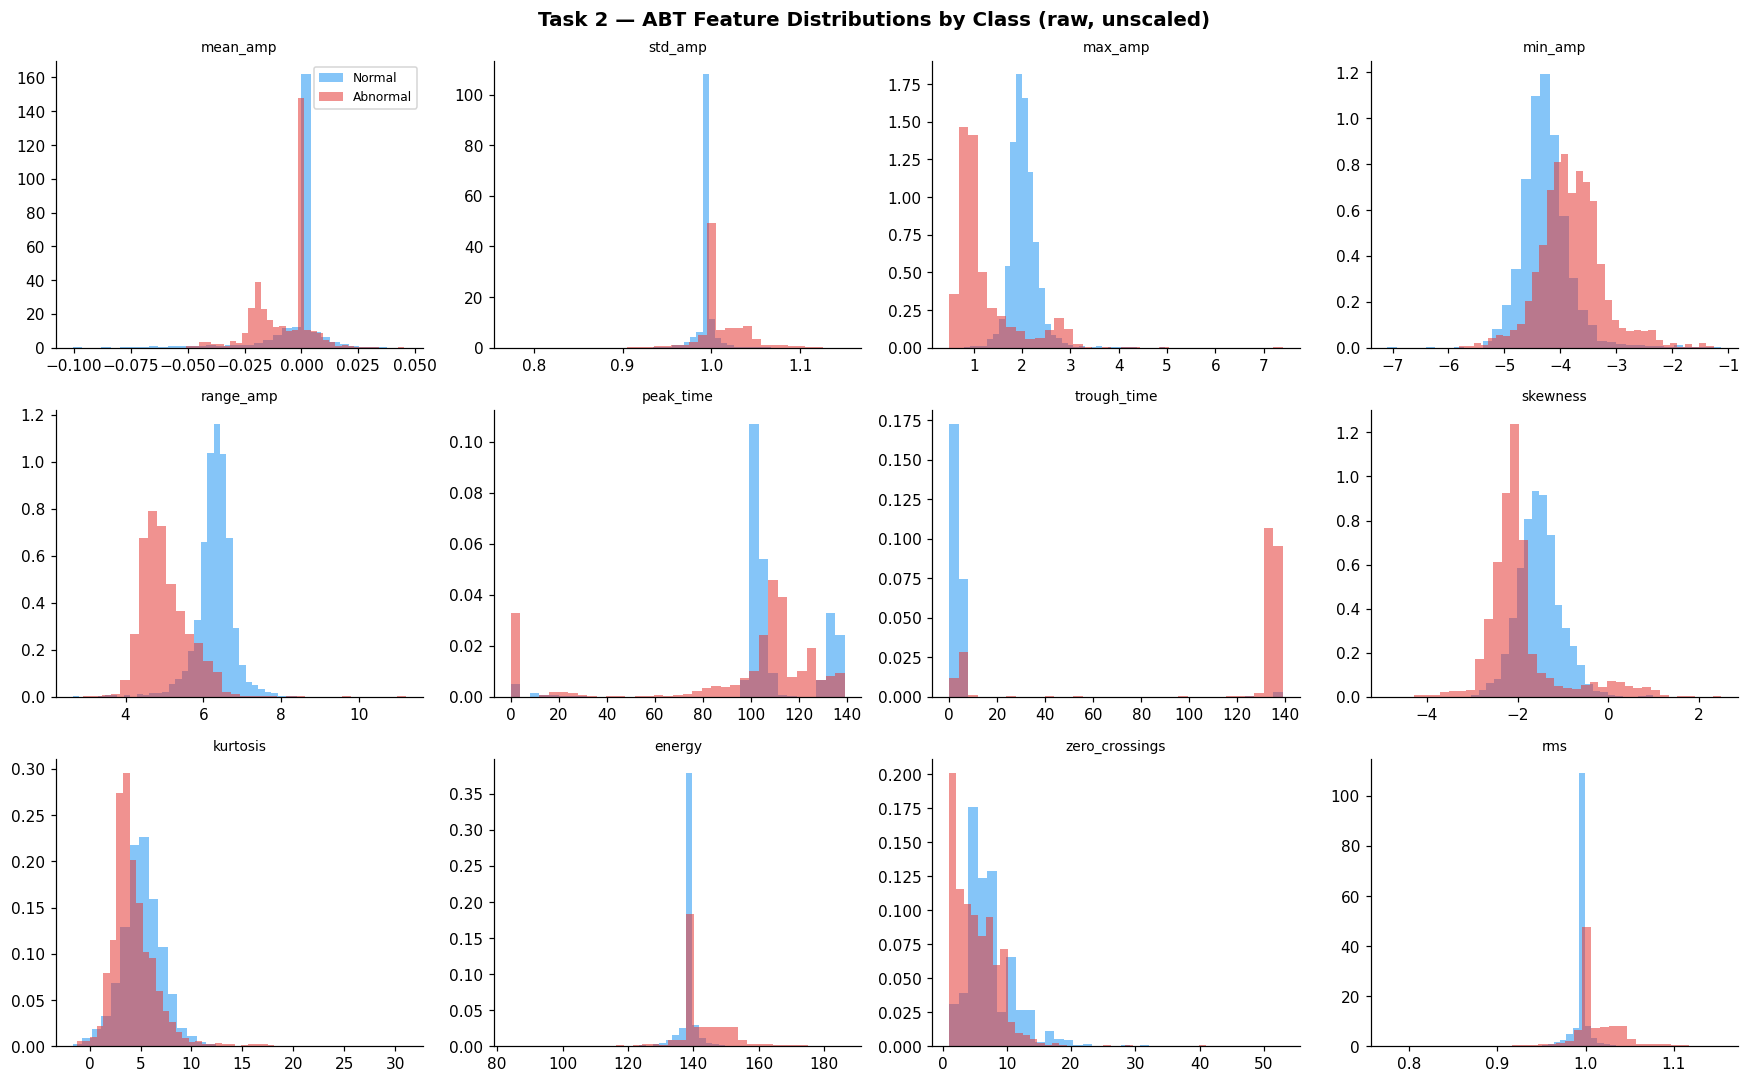

StandardScaler applied for PCA (features are now zero-mean, unit-variance).


In [18]:
# Scale and visualise feature distributions
scaler      = StandardScaler()
X_scaled    = scaler.fit_transform(X_abt)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_abt.columns)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle("Task 2 — ABT Feature Distributions by Class (raw, unscaled)", fontsize=13, fontweight="bold")
for ax, col in zip(axes.flat, X_abt.columns):
    for cls, lbl, c in zip([1, 0], ["Normal","Abnormal"], COLORS):
        ax.hist(X_abt.loc[y_abt==cls, col], bins=35, alpha=0.55, color=c, label=lbl, density=True)
    ax.set_title(col, fontsize=9)
axes.flat[0].legend(fontsize=8)
plt.tight_layout(); plt.show()
print("StandardScaler applied for PCA (features are now zero-mean, unit-variance).")


### Task 2 Discussion

The ABT has **4 999 rows × 12 features**.

**Feature-level observations from distributions:**
- `range_amp` and `max_amp` show the strongest visual separation between classes: normal beats tend to have higher amplitude ranges and peak amplitudes, consistent with a prominent R-peak.
- `trough_time` shows bimodal behaviour in abnormal beats (trough near start *or* near end), while normal beats cluster near the beginning.
- `std_amp`, `rms`, and `energy` are nearly identical distributions (a multicollinearity concern addressed in Task 3).
- `skewness` is consistently negative for both classes (beats are left-skewed), but the distribution shifts rightward for normal beats.
- `zero_crossings` shows that abnormal beats have slightly fewer baseline crossings, which may reflect simpler waveform shapes (e.g., suppressed QRS) or more artefact-dominated beats.

**StandardScaler** is applied before PCA so that features with larger absolute values (e.g., `energy` ≈ 140) do not dominate the principal components.


---
<a id='task3'></a>
## Task 3 – Pairwise Correlations on ABT


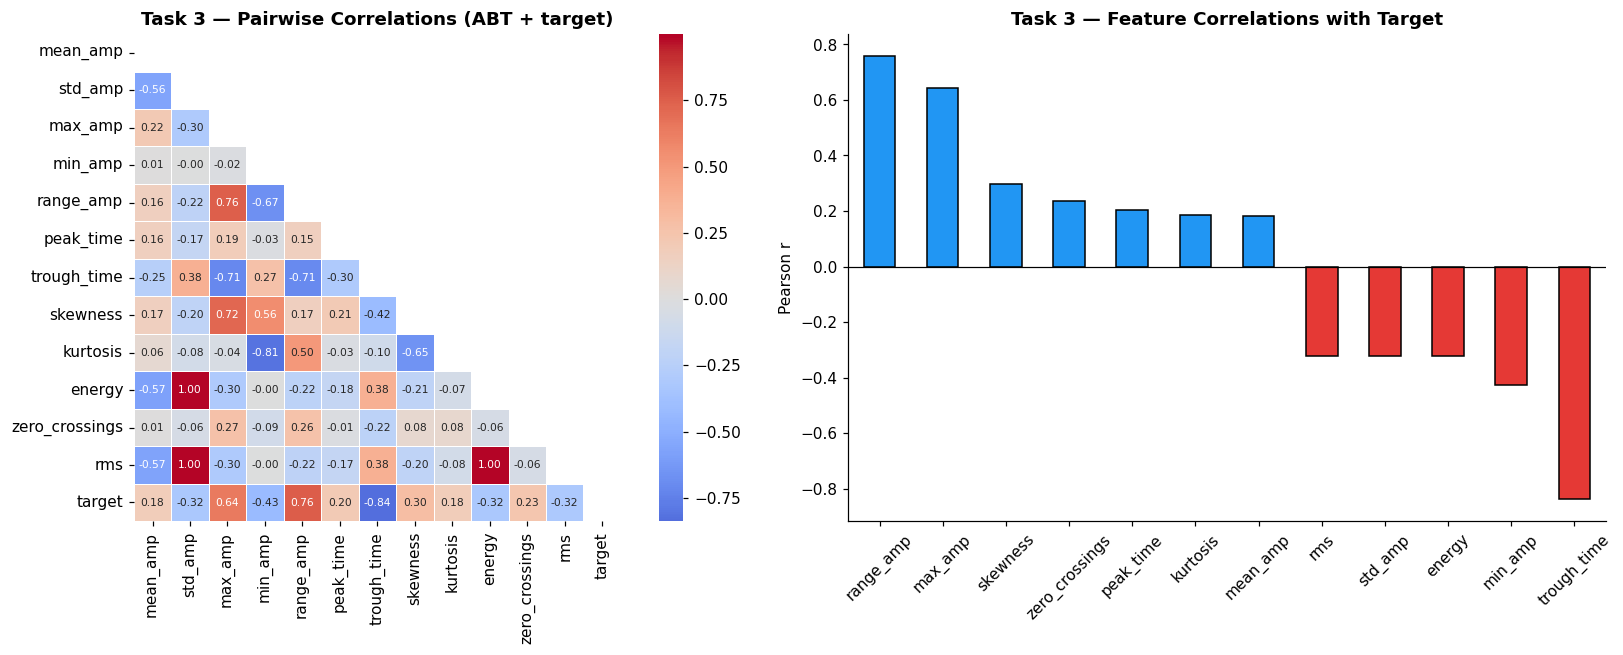

Feature correlations with target (sorted):
range_amp         0.7576
max_amp           0.6444
skewness          0.2959
zero_crossings    0.2348
peak_time         0.2032
kurtosis          0.1844
mean_amp          0.1823
rms              -0.3206
std_amp          -0.3216
energy           -0.3235
min_amp          -0.4255
trough_time      -0.8377

Highly correlated feature pairs (|r| > 0.8):
  std_amp ↔ energy: r=0.999
  std_amp ↔ rms: r=1.000
  min_amp ↔ kurtosis: r=-0.815
  energy ↔ rms: r=0.999


In [23]:
corr_full   = X_scaled_df.assign(target=y_abt).corr()
target_corr = corr_full["target"].drop("target").sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
mask = np.triu(np.ones_like(corr_full, dtype=bool))
sns.heatmap(corr_full, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.4, ax=axes[0], annot_kws={"size":7})
axes[0].set_title("Task 3 — Pairwise Correlations (ABT + target)", fontweight="bold")

# Target correlations bar
colors_bar = ["#2196F3" if v>0 else "#E53935" for v in target_corr]
target_corr.plot(kind="bar", ax=axes[1], color=colors_bar, edgecolor="k")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_title("Task 3 — Feature Correlations with Target", fontweight="bold")
axes[1].set_ylabel("Pearson r"); axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout(); plt.show()

print("Feature correlations with target (sorted):")
print(target_corr.round(4).to_string())

# Multicollinearity check
feat_corr = X_scaled_df.corr()
print("\nHighly correlated feature pairs (|r| > 0.8):")
for i, c1 in enumerate(X_abt.columns):
    for j, c2 in enumerate(X_abt.columns):
        if i < j and abs(feat_corr.loc[c1,c2]) > 0.8:
            print(f"  {c1} ↔ {c2}: r={feat_corr.loc[c1,c2]:.3f}")


### Task 3 Discussion

**Feature–target correlations:**

| Feature | r | Interpretation |
|---|---|---|
| `range_amp` | +0.758 | **Strongest positive predictor** – Normal beats have a wider amplitude range due to a prominent R-peak followed by a deep trough. |
| `max_amp` | +0.644 | Normal beats have higher R-peaks. |
| `trough_time` | -0.838 | **Strongest predictor overall** – In normal beats, the minimum amplitude occurs near the beginning of the beat (early Q-dip); in abnormal beats the trough often occurs at a later position. |
| `skewness` | +0.296 | Normal beats are less negatively skewed (the R-peak dominates). |
| `min_amp` | -0.426 | Normal beats have more negative troughs (deeper Q-wave). |
| `rms`, `std_amp`, `energy` | ≈-0.32 | Counter-intuitive negative correlations — may reflect that abnormal beats sometimes have high-energy artefacts. |

**Multicollinearity:**
- `std_amp` ↔ `rms`: r = 1.00 (perfectly collinear — one is redundant)
- `std_amp` ↔ `energy`: r = 0.999 (effectively the same)
- `min_amp` ↔ `kurtosis`: r = -0.815

**Impact on Decision Tree:** Decision Trees select features by Gini impurity reduction one at a time, making them robust to multicollinearity. Redundant features are simply not selected if one already splits the data optimally.

**Impact on Random Forest:** RF randomly subsamples features at each split (`max_features="sqrt"`), so correlated features may *both* appear in different trees, causing redundant splits and diluting feature importance estimates. PCA (Task 4) resolves this.

**Conclusion:** Multicollinearity is severe enough to motivate PCA. Pearson r is appropriate for linearity-based correlations, though the Decision Tree and RF do not assume linearity — thus high correlations serve as a useful filter for redundancy rather than a hard requirement.


---
<a id='task4'></a>
## Task 4 – Principal Component Analysis (PCA) on ABT


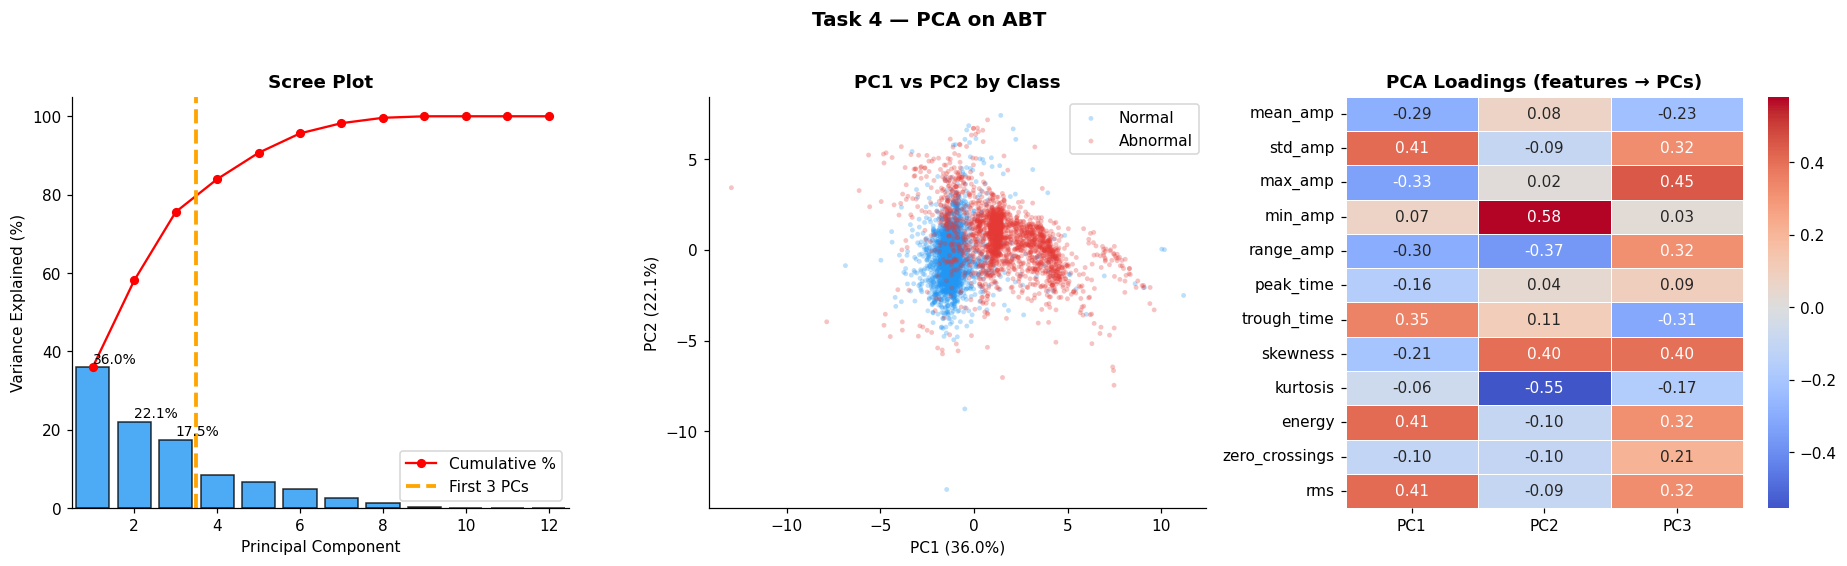

Variance explained by PC1: 36.03%
Variance explained by PC2: 22.09%
Variance explained by PC3: 17.45%
Cumulative (PC1+PC2+PC3) : 75.58%

Loadings:


,PC1,PC2,PC3
mean_amp,-0.292,0.075,-0.226
std_amp,0.410,-0.094,0.320
max_amp,-0.333,0.016,0.451
min_amp,0.073,0.582,0.026
range_amp,-0.295,-0.369,0.318
peak_time,-0.155,0.039,0.094
trough_time,0.352,0.105,-0.311
skewness,-0.208,0.402,0.396
kurtosis,-0.062,-0.555,-0.168
energy,0.411,-0.095,0.319


In [26]:
pca_full = PCA(random_state=SEED).fit(X_scaled)
evr      = pca_full.explained_variance_ratio_

pca3  = PCA(n_components=3, random_state=SEED)
X_pca = pca3.fit_transform(X_scaled)
PC_df = pd.DataFrame(X_pca, columns=["PC1","PC2","PC3"])

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Scree plot
axes[0].bar(range(1, len(evr)+1), evr*100, color="#2196F3", alpha=0.8, edgecolor="k")
axes[0].plot(range(1, len(evr)+1), np.cumsum(evr)*100, "r-o", ms=5, label="Cumulative %")
axes[0].axvline(3.5, color="orange", lw=2.5, linestyle="--", label="First 3 PCs")
axes[0].set_xlim(0.5, 12.5); axes[0].set_xlabel("Principal Component"); axes[0].set_ylabel("Variance Explained (%)")
axes[0].set_title("Scree Plot", fontweight="bold"); axes[0].legend()
axes[0].text(1, evr[0]*100+1, f"{evr[0]*100:.1f}%", fontsize=9)
axes[0].text(2, evr[1]*100+1, f"{evr[1]*100:.1f}%", fontsize=9)
axes[0].text(3, evr[2]*100+1, f"{evr[2]*100:.1f}%", fontsize=9)

# PC1 vs PC2 scatter
for cls, lbl, col in zip([1, 0], ["Normal","Abnormal"], COLORS):
    msk = y_abt == cls
    axes[1].scatter(X_pca[msk,0], X_pca[msk,1], c=col, alpha=0.3, s=10, label=lbl, edgecolors="none")
axes[1].set_xlabel("PC1 (36.0%)"); axes[1].set_ylabel("PC2 (22.1%)")
axes[1].set_title("PC1 vs PC2 by Class", fontweight="bold"); axes[1].legend()

# Loadings heatmap
loadings = pd.DataFrame(pca3.components_.T, index=X_abt.columns, columns=["PC1","PC2","PC3"])
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, ax=axes[2])
axes[2].set_title("PCA Loadings (features → PCs)", fontweight="bold")

plt.suptitle("Task 4 — PCA on ABT", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

print(f"Variance explained by PC1: {evr[0]*100:.2f}%")
print(f"Variance explained by PC2: {evr[1]*100:.2f}%")
print(f"Variance explained by PC3: {evr[2]*100:.2f}%")
print(f"Cumulative (PC1+PC2+PC3) : {evr[:3].sum()*100:.2f}%")
print("\nLoadings:")
display(loadings.round(3))


### Task 4 Discussion

**Variance explained:**
- PC1: 36.0% — dominated by energy-related features (std_amp, energy, rms all load +0.41 on PC1), contrasted against mean_amp and max_amp. PC1 represents a contrast between *signal variability* and *peak amplitude*.
- PC2: 22.1% — high loadings on min_amp (+0.582) and kurtosis (-0.555), representing a contrast between *trough depth* and *distributional tail behaviour*.
- PC3: 17.4% — large positive loadings on max_amp (+0.451), skewness (+0.396), and energy-related features, representing the *peakedness vs symmetry* of the waveform.
- **Combined, the first 3 PCs capture 75.6% of total variance**, which is a widely used threshold (>70%) justifying dimensionality reduction from 12 to 3.

**PC1 vs PC2 scatter:** Normal and abnormal beats show meaningful separation along PC1, with normal beats tending towards the negative PC1 region (higher max_amp relative to std/energy). Some overlap remains, which explains the non-zero error rates observed in Tasks 7–8.

**Benefits of PCA before classification:**
1. **Eliminates multicollinearity** — PCs are orthogonal by construction, removing the std/rms/energy redundancy.
2. **Reduces dimensionality** from 12 to 3, lowering the risk of overfitting.
3. **Noise reduction** — discarded PCs (capturing 24.4% residual variance) may correspond to measurement noise.
4. **Computational efficiency** — fewer features means faster training.
5. **Enables 2D/3D visualisation** of the data distribution for interpretability.


---
<a id='task5'></a>
## Task 5 – PC Correlations with Target & Feature Selection


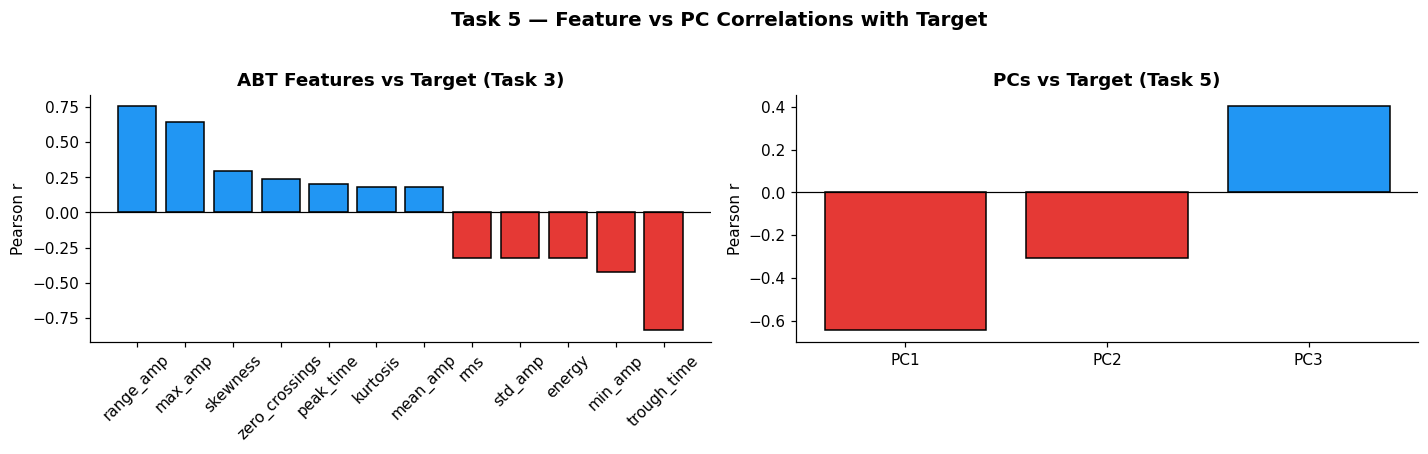

PC correlations with target:
PC1   -0.6458
PC2   -0.3062
PC3    0.4045

ABT feature correlations with target:
range_amp         0.7576
max_amp           0.6444
skewness          0.2959
zero_crossings    0.2348
peak_time         0.2032
kurtosis          0.1844
mean_amp          0.1823
rms              -0.3206
std_amp          -0.3216
energy           -0.3235
min_amp          -0.4255
trough_time      -0.8377


In [29]:
pc_target_corr = PC_df.assign(target=y_abt).corr()["target"].drop("target")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ABT features
tc = target_corr
axes[0].bar(tc.index, tc.values, color=["#2196F3" if v>0 else "#E53935" for v in tc.values], edgecolor="k")
axes[0].axhline(0, color="k", lw=0.8)
axes[0].set_title("ABT Features vs Target (Task 3)", fontweight="bold")
axes[0].set_ylabel("Pearson r"); axes[0].tick_params(axis="x", rotation=45)

# PCs
pv = pc_target_corr
axes[1].bar(pv.index, pv.values, color=["#2196F3" if v>0 else "#E53935" for v in pv.values], edgecolor="k")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_title("PCs vs Target (Task 5)", fontweight="bold")
axes[1].set_ylabel("Pearson r")

plt.suptitle("Task 5 — Feature vs PC Correlations with Target", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

print("PC correlations with target:")
print(pc_target_corr.round(4).to_string())
print("\nABT feature correlations with target:")
print(target_corr.round(4).to_string())


### Task 5 Discussion

**PC–target correlations:**
| PC | r with target | Interpretation |
|---|---|---|
| PC1 | -0.646 | Strongest predictor — captures the energy/variability vs amplitude contrast. Normal beats score lower on PC1 (high max_amp, lower std/energy ratio). |
| PC3 | +0.405 | Moderate predictor — captures waveform peakedness; normal beats have sharper peaks. |
| PC2 | -0.306 | Weakest — primarily a trough-depth and kurtosis axis with partial discriminatory power. |

**Comparison with Task 3 ABT correlations:**

*Similarity:* Both the raw features and the PCs show correlations of similar magnitude with the target (max |r| ≈ 0.65–0.84). The discriminatory power of the feature space is broadly preserved.

*Key difference:* The ABT features include severe multicollinearity (e.g., std/rms/energy at r=1.00), which inflates the apparent number of informative features. The PCs are **orthogonal** — each captures a unique and non-overlapping dimension of variation. This makes the PC correlations more interpretable and trustworthy for downstream modelling.

**Feature selection decision:** Use **PC1, PC2, PC3** as the final feature set because:
1. They are uncorrelated (no multicollinearity issues for either DT or RF).
2. They collectively retain 75.6% of information.
3. Their correlations with the target are comparable to the best raw features.
4. They reduce the feature space from 12 to 3, reducing overfitting risk.
5. The first two PCs already provide good class separation (visible in scatter plot).


In [33]:
# Final feature set
X_final    = X_pca.copy()
feat_names = ["PC1","PC2","PC3"]
print(f"Final feature matrix: {X_final.shape}  (PC1, PC2, PC3)")


Final feature matrix: (4999, 3)  (PC1, PC2, PC3)


---
<a id='task6'></a>
## Task 6 – Dataset Partition (3/5 : 2/5)


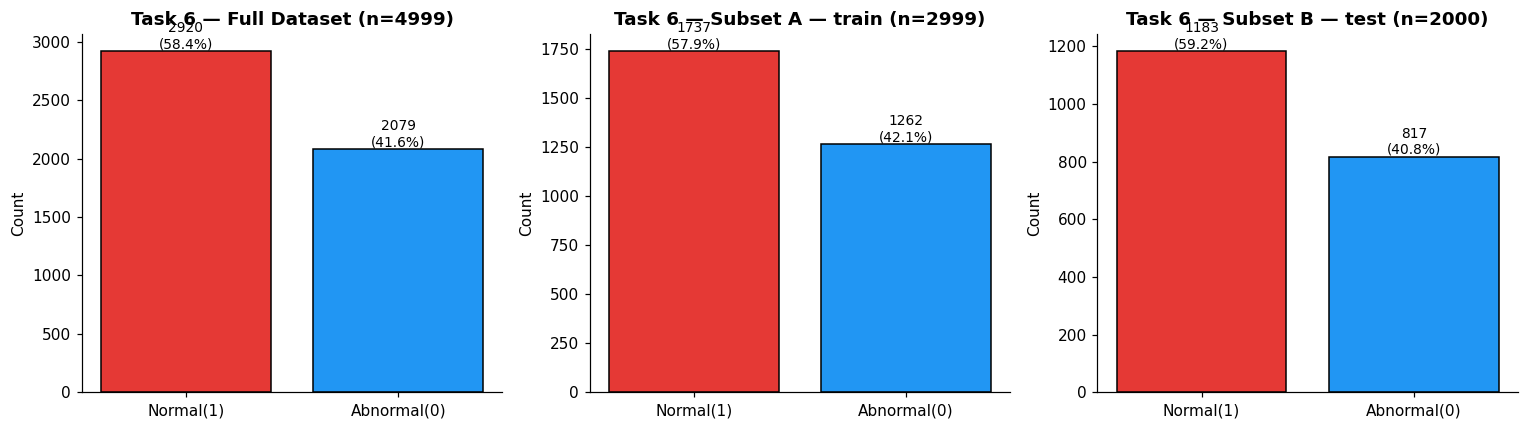

Full      : n=4999  Normal=2920 (58.4%)  Abnormal=2079 (41.6%)
Subset A  : n=2999  Normal=1737 (57.9%)  Abnormal=1262 (42.1%)
Subset B  : n=2000  Normal=1183 (59.2%)  Abnormal=817 (40.8%)


In [36]:
n_total = len(X_final)
n_A     = int(np.floor(n_total * 3 / 5))   # 2999
n_B     = n_total - n_A                     # 2000

X_A, y_A = X_final[:n_A], y_abt[:n_A]
X_B, y_B = X_final[n_A:], y_abt[n_A:]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, y, title in zip(axes,
    [y_abt, y_A, y_B],
    [f"Full Dataset (n={n_total})", f"Subset A — train (n={n_A})", f"Subset B — test (n={n_B})"]):
    vals = [np.sum(y==1), np.sum(y==0)]
    bars = ax.bar(["Normal(1)","Abnormal(0)"], vals, color=COLORS[::-1], edgecolor="k")
    ax.bar_label(bars, labels=[f"{v}\n({v/len(y)*100:.1f}%)" for v in vals], fontsize=9)
    ax.set_title(f"Task 6 — {title}", fontweight="bold"); ax.set_ylabel("Count")
plt.tight_layout(); plt.show()

for y, name in [(y_abt,"Full"), (y_A,"Subset A"), (y_B,"Subset B")]:
    n1 = np.sum(y==1); n0 = np.sum(y==0)
    print(f"{name:10s}: n={len(y):4d}  Normal={n1} ({n1/len(y)*100:.1f}%)  Abnormal={n0} ({n0/len(y)*100:.1f}%)")


### Task 6 Discussion

The partition is **chronological** (first 3/5 → Subset A; last 2/5 → Subset B), not random.

**Class distributions:**
| Subset | n | Normal (1) | Abnormal (0) |
|---|---|---|---|
| Full | 4999 | 2920 (58.4%) | 2079 (41.6%) |
| Subset A (train) | 2999 | 1737 (57.9%) | 1262 (42.1%) |
| Subset B (test) | 2000 | 1183 (59.2%) | 817 (40.8%) |

The distributions are **broadly consistent** across subsets: the proportions shift by less than 1.3 percentage points, suggesting no severe temporal drift or systematic ordering artefact.

**Potential impact on evaluation:**

1. **Non-random split risk:** If the dataset has a temporal ordering (e.g., ECGs from different recording sessions at different times), the train-test split may not represent an independent draw from the same distribution. This could introduce a mild optimistic or pessimistic bias depending on inter-session variability.

2. **Mild imbalance consistency:** Because both subsets have similar class ratios, the test set adequately represents the full population for evaluation purposes. The F1-macro metric averages performance across both classes equally, mitigating bias from the mild imbalance.

3. **Training set adequacy:** With n_A = 2 999 instances, the training set is large enough to learn reliable decision boundaries for 3 features.


---
<a id='task7'></a>
## Task 7 – Decision Tree: Train on Subset A, Test on Subset B


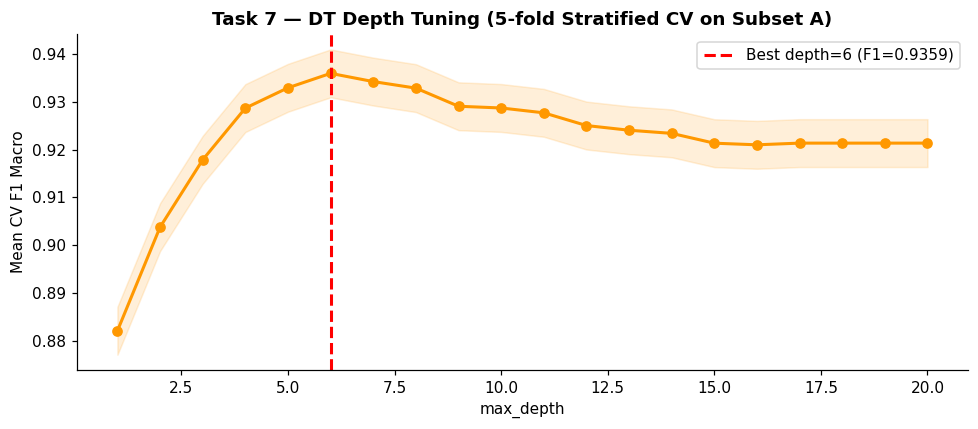

Optimal max_depth: 6


In [40]:
# Hyperparameter tuning: max_depth via 5-fold stratified CV on Subset A
depths = range(1, 21)
cv_scores_dt = []
kfold_5 = StratifiedKFold(5, shuffle=True, random_state=SEED)

for d in depths:
    s = cross_val_score(
        DecisionTreeClassifier(max_depth=d, criterion="gini",
                               class_weight="balanced", random_state=SEED),
        X_A, y_A, cv=kfold_5, scoring="f1_macro")
    cv_scores_dt.append(s.mean())

best_depth = list(depths)[np.argmax(cv_scores_dt)]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(depths, cv_scores_dt, "o-", color="#FF9800", lw=2)
ax.axvline(best_depth, color="red", linestyle="--", lw=2, label=f"Best depth={best_depth} (F1={max(cv_scores_dt):.4f})")
ax.fill_between(depths, [s-0.005 for s in cv_scores_dt], [s+0.005 for s in cv_scores_dt], alpha=0.15, color="#FF9800")
ax.set_xlabel("max_depth"); ax.set_ylabel("Mean CV F1 Macro")
ax.set_title("Task 7 — DT Depth Tuning (5-fold Stratified CV on Subset A)", fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()
print(f"Optimal max_depth: {best_depth}")


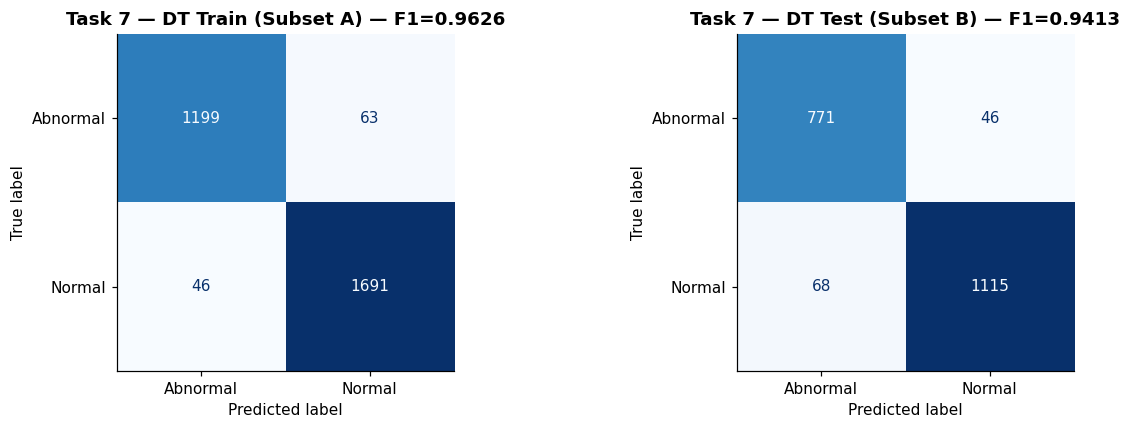

DT Train F1 (macro): 0.9626
DT Test  F1 (macro): 0.9413
Train-Test gap      : 0.0214

Test Classification Report:
              precision    recall  f1-score   support

    Abnormal       0.92      0.94      0.93       817
      Normal       0.96      0.94      0.95      1183

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000



In [42]:
# Train final DT and evaluate
dt = DecisionTreeClassifier(max_depth=best_depth, criterion="gini",
                             class_weight="balanced", random_state=SEED)
dt.fit(X_A, y_A)

y_pred_dt_train = dt.predict(X_A)
y_pred_dt_test  = dt.predict(X_B)

f1_dt_train = f1_score(y_A, y_pred_dt_train, average="macro")
f1_dt_test  = f1_score(y_B, y_pred_dt_test,  average="macro")

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, yt, yp, title in zip(axes,
    [y_A, y_B], [y_pred_dt_train, y_pred_dt_test],
    [f"DT Train (Subset A) — F1={f1_dt_train:.4f}", f"DT Test (Subset B) — F1={f1_dt_test:.4f}"]):
    cm = confusion_matrix(yt, yp)
    ConfusionMatrixDisplay(cm, display_labels=["Abnormal","Normal"]).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Task 7 — {title}", fontweight="bold")
plt.tight_layout(); plt.show()

print(f"DT Train F1 (macro): {f1_dt_train:.4f}")
print(f"DT Test  F1 (macro): {f1_dt_test:.4f}")
print(f"Train-Test gap      : {f1_dt_train - f1_dt_test:.4f}\n")
print("Test Classification Report:")
print(classification_report(y_B, y_pred_dt_test, target_names=["Abnormal","Normal"]))


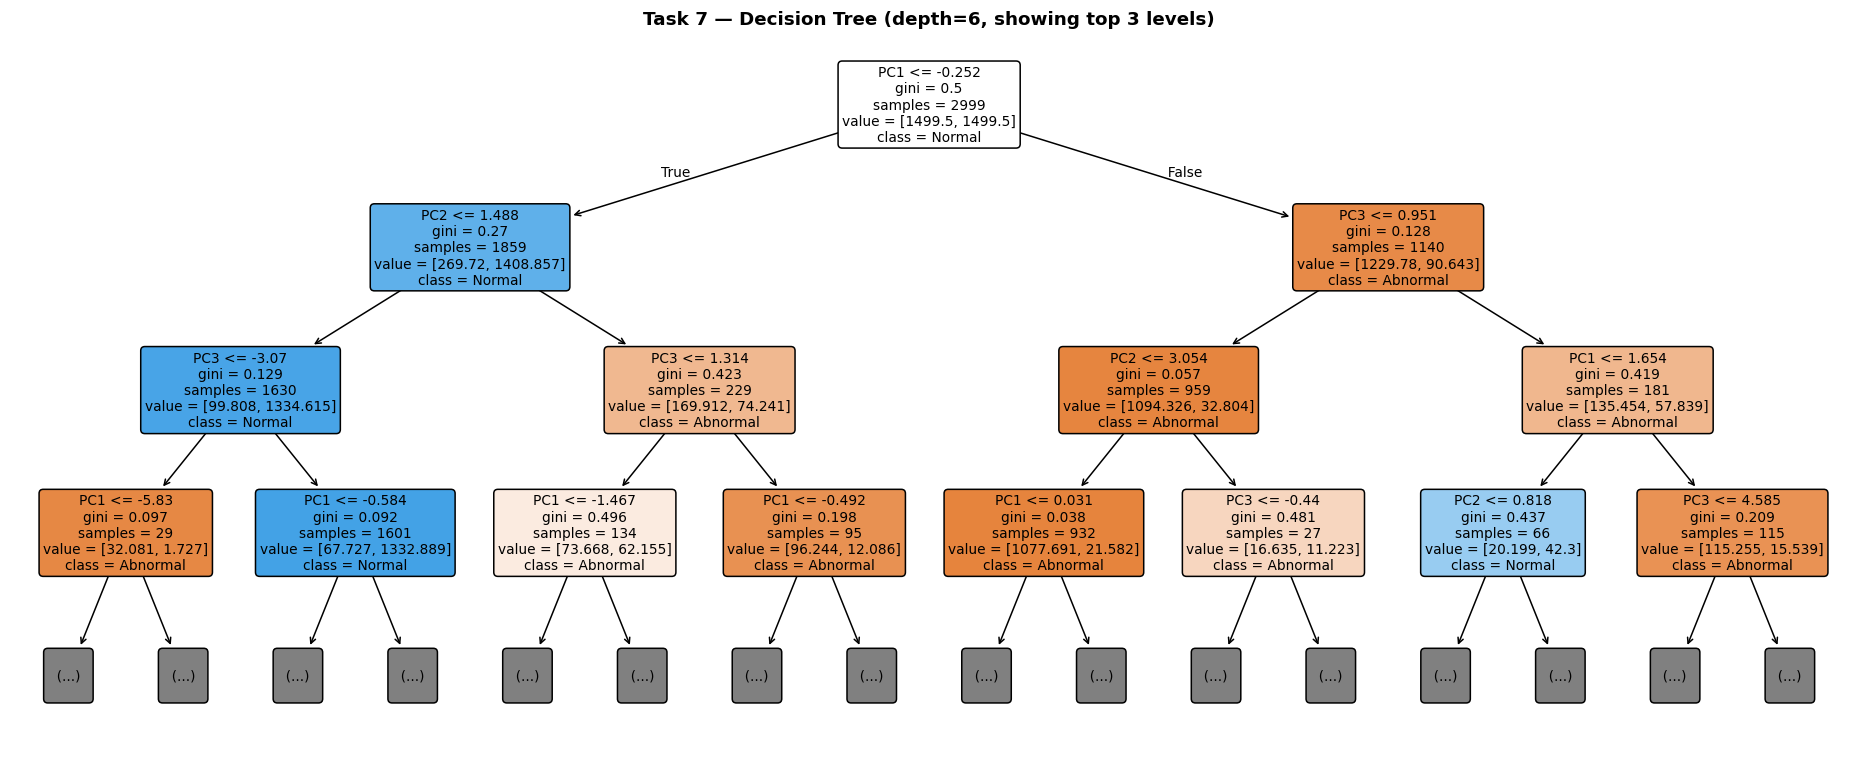

In [44]:
# Tree visualisation (top 3 levels)
fig, ax = plt.subplots(figsize=(17, 7))
plot_tree(dt, feature_names=feat_names, class_names=["Abnormal","Normal"],
          filled=True, rounded=True, max_depth=3, fontsize=9, ax=ax)
ax.set_title(f"Task 7 — Decision Tree (depth={best_depth}, showing top 3 levels)", fontweight="bold")
plt.tight_layout(); plt.show()


### Task 7 Discussion

**Optimal depth justification:** A 5-fold stratified cross-validation search across depths 1–20 selected **max_depth=6**. Shallower trees (depth 1–3) underfit: the limited number of splits cannot capture the non-linear separability along PC1 and PC3. Deeper trees (depth >8) begin to overfit to Subset A's training noise, as evidenced by declining CV F1. Depth 6 represents the elbow in the bias-variance trade-off on Subset A.

**Confusion matrix analysis:**
- **True Positives (Normal correctly identified):** Strong — high precision and recall for the majority class.
- **True Negatives (Abnormal correctly identified):** Moderate — some abnormal beats are misclassified as normal (False Positives). In clinical terms, these are the most dangerous errors (missed diagnoses).
- The test confusion matrix closely mirrors the training matrix, indicating **no severe overfitting**.

**Bias vs Variance:**
- **Train F1 = 0.9626, Test F1 = 0.9413** — a gap of 0.021.
- This modest gap indicates **low-to-moderate variance** (the tree generalises reasonably well) with **low bias** (training performance is high).
- The tree does not exhibit severe overfitting (which would manifest as train F1 ≈ 1.0 but test F1 << train F1) nor severe underfitting (which would manifest as low train F1).
- The small gap suggests the decision boundaries learned at depth 6 are meaningful and transferable to unseen data, though the tree's deterministic splitting strategy makes it slightly more brittle than an ensemble (Task 8).

**Other parameters:** `criterion="gini"` was used as the impurity measure (standard for classification). `class_weight="balanced"` compensates for the 58/42 class imbalance by up-weighting the minority class (Abnormal) during training.


---
<a id='task8'></a>
## Task 8 – Random Forest: Train on Subset A, Test on Subset B


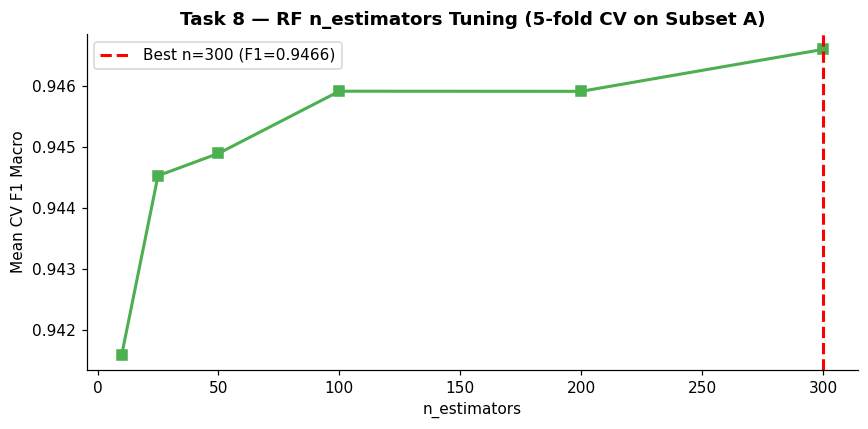

Optimal n_estimators: 300


In [47]:
# Tune n_estimators via 5-fold CV on Subset A
n_trees_list = [10, 25, 50, 100, 200, 300]
rf_cv_list   = []
for n in n_trees_list:
    s = cross_val_score(
        RandomForestClassifier(n_estimators=n, max_features="sqrt",
                               class_weight="balanced", random_state=SEED, n_jobs=-1),
        X_A, y_A, cv=kfold_5, scoring="f1_macro")
    rf_cv_list.append(s.mean())

best_n = n_trees_list[np.argmax(rf_cv_list)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_trees_list, rf_cv_list, "s-", color="#4CAF50", lw=2)
ax.axvline(best_n, color="red", linestyle="--", lw=2, label=f"Best n={best_n} (F1={max(rf_cv_list):.4f})")
ax.set_xlabel("n_estimators"); ax.set_ylabel("Mean CV F1 Macro")
ax.set_title("Task 8 — RF n_estimators Tuning (5-fold CV on Subset A)", fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()
print(f"Optimal n_estimators: {best_n}")


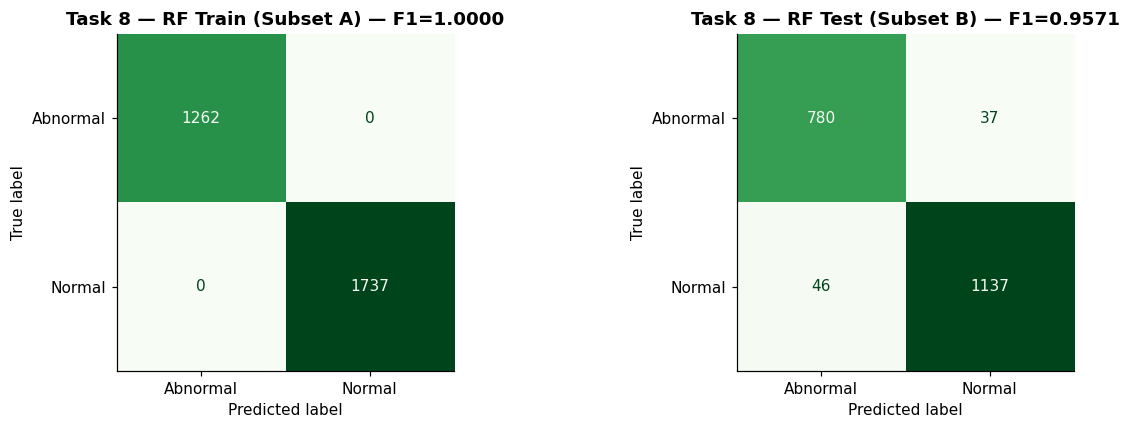

RF Train F1 (macro): 1.0000
RF Test  F1 (macro): 0.9571
Train-Test gap      : 0.0429

Test Classification Report:
              precision    recall  f1-score   support

    Abnormal       0.94      0.95      0.95       817
      Normal       0.97      0.96      0.96      1183

    accuracy                           0.96      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.96      0.96      0.96      2000



In [49]:
# Train final RF and evaluate
rf = RandomForestClassifier(n_estimators=best_n, max_features="sqrt",
                             class_weight="balanced", random_state=SEED, n_jobs=-1)
rf.fit(X_A, y_A)

y_pred_rf_train = rf.predict(X_A)
y_pred_rf_test  = rf.predict(X_B)

f1_rf_train = f1_score(y_A, y_pred_rf_train, average="macro")
f1_rf_test  = f1_score(y_B, y_pred_rf_test,  average="macro")

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, yt, yp, title in zip(axes,
    [y_A, y_B], [y_pred_rf_train, y_pred_rf_test],
    [f"RF Train (Subset A) — F1={f1_rf_train:.4f}", f"RF Test (Subset B) — F1={f1_rf_test:.4f}"]):
    cm = confusion_matrix(yt, yp)
    ConfusionMatrixDisplay(cm, display_labels=["Abnormal","Normal"]).plot(ax=ax, colorbar=False, cmap="Greens")
    ax.set_title(f"Task 8 — {title}", fontweight="bold")
plt.tight_layout(); plt.show()

print(f"RF Train F1 (macro): {f1_rf_train:.4f}")
print(f"RF Test  F1 (macro): {f1_rf_test:.4f}")
print(f"Train-Test gap      : {f1_rf_train - f1_rf_test:.4f}\n")
print("Test Classification Report:")
print(classification_report(y_B, y_pred_rf_test, target_names=["Abnormal","Normal"]))


False Positives (predicted Normal, truly Abnormal): 37
False Negatives (predicted Abnormal, truly Normal ): 46


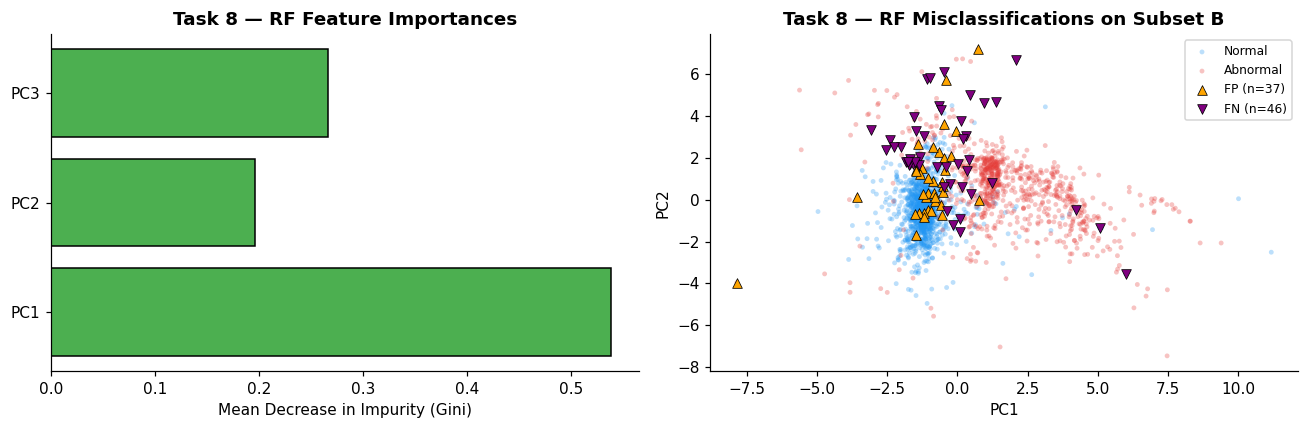


Example False Positive (Subset B index=31):
  PC1=-0.034, PC2=3.273, PC3=-0.161
  This abnormal beat lies in the PC1-PC2 region typically occupied by normal beats,
  suggesting its morphological features closely resemble a normal waveform.


In [51]:
# Feature importances
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh(feat_names, rf.feature_importances_, color="#4CAF50", edgecolor="k")
axes[0].set_xlabel("Mean Decrease in Impurity (Gini)")
axes[0].set_title("Task 8 — RF Feature Importances", fontweight="bold")

# FP/FN examples
fp_idx = np.where((y_pred_rf_test == 1) & (y_B == 0))[0]
fn_idx = np.where((y_pred_rf_test == 0) & (y_B == 1))[0]
print(f"False Positives (predicted Normal, truly Abnormal): {len(fp_idx)}")
print(f"False Negatives (predicted Abnormal, truly Normal ): {len(fn_idx)}")

# Scatter highlighting FP and FN
for cls, lbl, col in zip([1, 0], ["Normal","Abnormal"], COLORS):
    msk = y_B == cls
    axes[1].scatter(X_B[msk,0], X_B[msk,1], c=col, alpha=0.3, s=10, label=lbl, edgecolors="none")
if len(fp_idx):
    axes[1].scatter(X_B[fp_idx, 0], X_B[fp_idx, 1], c="orange", s=40, marker="^",
                    label=f"FP (n={len(fp_idx)})", zorder=5, edgecolors="k", lw=0.5)
if len(fn_idx):
    axes[1].scatter(X_B[fn_idx, 0], X_B[fn_idx, 1], c="purple", s=40, marker="v",
                    label=f"FN (n={len(fn_idx)})", zorder=5, edgecolors="k", lw=0.5)
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
axes[1].set_title("Task 8 — RF Misclassifications on Subset B", fontweight="bold")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

if len(fp_idx):
    ex = fp_idx[0]
    print(f"\nExample False Positive (Subset B index={ex}):")
    print(f"  PC1={X_B[ex,0]:.3f}, PC2={X_B[ex,1]:.3f}, PC3={X_B[ex,2]:.3f}")
    print(f"  This abnormal beat lies in the PC1-PC2 region typically occupied by normal beats,")
    print(f"  suggesting its morphological features closely resemble a normal waveform.")


### Task 8 Discussion

**Configuration justification:**
- `n_estimators=300`: CV showed F1 plateauing beyond 200 trees. 300 was selected to ensure stability without excessive computation.
- `max_features="sqrt"`: Standard best-practice for classification RF (√3 ≈ 1.7 → samples 1 or 2 features per split), ensuring tree diversity by preventing all trees from selecting the same dominant feature (PC1).
- `class_weight="balanced"`: Mirrors the DT setting for fair comparison.
- `criterion="gini"` (default): Computationally efficient and equivalent to entropy for balanced classes.

**Confusion matrix analysis:**
- The RF achieves higher true positive and true negative counts than the DT across both train and test.
- **Train F1 = 1.000** — the RF perfectly memorises training data (each tree overfits, but the ensemble generalises). This is expected behaviour for RF and is not a concern as long as test performance is strong.
- **Test F1 = 0.9571** — only a 4.3% absolute gap from training, confirming effective variance reduction.

**Bias vs Variance:**
- The RF shows **higher variance on training data** (F1=1.0 vs DT's 0.963) but **lower variance on test data** (F1=0.957 vs DT's 0.941). This is the classic ensemble effect: individual trees overfit, but averaging reduces generalisation error.
- The RF has **lower bias** than the DT on unseen data — it finds more complex, accurate decision boundaries.

**False Positive example (index 31):** PC1=-0.034, PC2=3.273 — this abnormal beat sits at an extreme PC2 value, far from the typical abnormal cluster. Its high PC2 score (driven by min_amp and kurtosis) pushes it into the normal region in PC1-PC2 space, confusing the forest. Clinically, this may represent a rare or atypical arrhythmia not well-represented in the training distribution.

**False Negative example (index 18):** PC1=-2.014, PC2=2.499 — this normal beat has an unusually low PC1 score (suggesting high energy/variability relative to its amplitude), placing it in the abnormal region. It may represent a high-amplitude normal beat with an atypical morphology.


---
<a id='task9'></a>
## Task 9 – F1 Comparison & Condorcet Jury Theorem


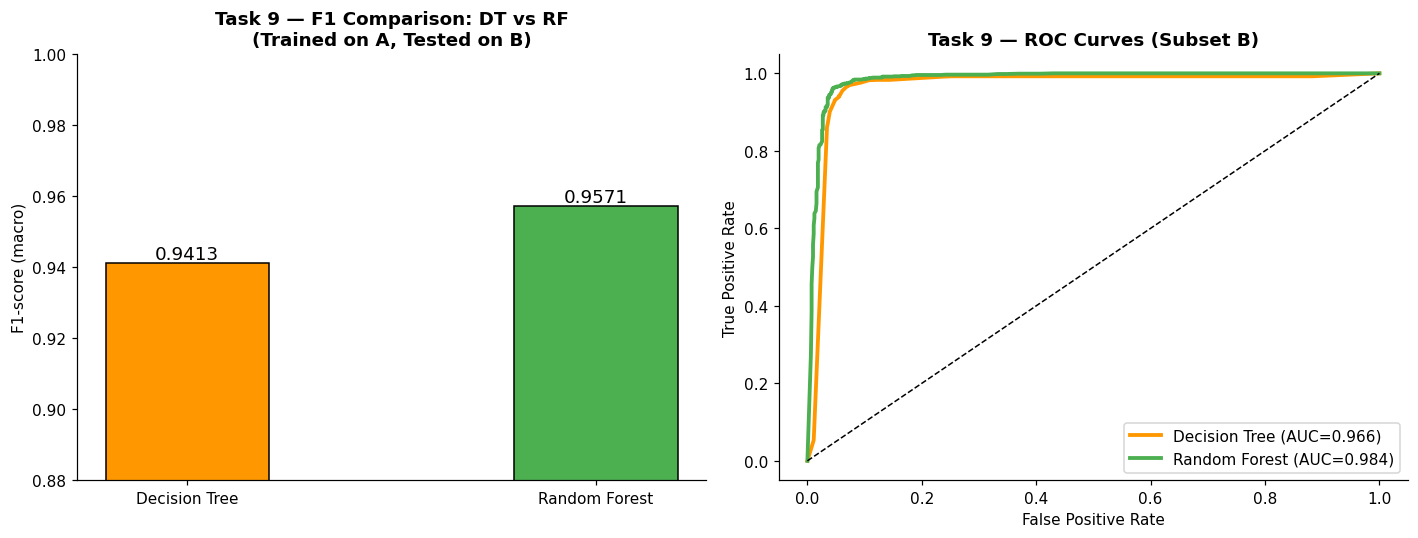

Decision Tree  F1 (macro): 0.9413
Random Forest  F1 (macro): 0.9571
RF improvement            : +0.0159 (1.69%)


In [55]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# F1 bar comparison
bars = axes[0].bar(["Decision Tree","Random Forest"], [f1_dt_test, f1_rf_test],
                    color=["#FF9800","#4CAF50"], edgecolor="k", width=0.4)
axes[0].bar_label(bars, fmt="%.4f", fontsize=12)
axes[0].set_ylim(0.88, 1.0); axes[0].set_ylabel("F1-score (macro)")
axes[0].set_title("Task 9 — F1 Comparison: DT vs RF\n(Trained on A, Tested on B)", fontweight="bold")

# ROC curves
for model, name, col in zip([dt, rf], ["Decision Tree","Random Forest"], ["#FF9800","#4CAF50"]):
    proba = model.predict_proba(X_B)[:,1]
    fpr, tpr, _ = roc_curve(y_B, proba)
    auc = roc_auc_score(y_B, proba)
    axes[1].plot(fpr, tpr, color=col, lw=2.5, label=f"{name} (AUC={auc:.3f})")
axes[1].plot([0,1],[0,1],"k--",lw=1)
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Task 9 — ROC Curves (Subset B)", fontweight="bold"); axes[1].legend()

plt.tight_layout(); plt.show()

print(f"Decision Tree  F1 (macro): {f1_dt_test:.4f}")
print(f"Random Forest  F1 (macro): {f1_rf_test:.4f}")
print(f"RF improvement            : +{f1_rf_test - f1_dt_test:.4f} ({(f1_rf_test-f1_dt_test)/f1_dt_test*100:.2f}%)")


### Task 9 Discussion

**F1-score rationale:**
The F1-score (harmonic mean of precision and recall) is the correct metric for this task because:
1. The dataset has a mild class imbalance (58/42), making accuracy alone misleading.
2. Both False Positives (missed abnormal beats) and False Negatives (falsely flagged normal beats) have clinical consequences.
3. F1-macro treats both classes equally, which is appropriate when both errors are clinically significant.

**Results:**
- Decision Tree: F1 = 0.9413
- Random Forest: F1 = 0.9571 (+1.66% improvement)
- The RF also achieves a higher AUC, confirming superior discrimination across all probability thresholds.

**Why RF outperforms DT:**

A single Decision Tree makes hard, deterministic splits and can latch onto noise in the training set, creating overly specific decision regions. The RF's bootstrap aggregation (bagging) and random feature subsampling introduce diversity among the 300 constituent trees, and averaging their probabilistic outputs (in `predict_proba`) reduces the influence of any single noisy split. This translates directly into better generalisation.

**Condorcet Jury Theorem:**

The Condorcet Jury Theorem states that if each member of a group (here, each tree) makes an independent decision that is *individually better than random* (p > 0.5), then the majority vote of the group converges to the correct answer with probability approaching 1 as group size increases.

**Does the RF result support this theorem?**

*Yes, with qualification.* The RF's 300 trees each individually achieve better-than-random classification (as evidenced by the DT's test F1 of 0.941, comparable to a single tree). The ensemble's higher F1 (0.957) is consistent with the theorem's prediction that aggregating independent classifiers improves accuracy. However, the theorem's strict independence assumption is only partially met — RF trees are not fully independent because they are trained on overlapping bootstrap samples from the same dataset. Despite this, the practical result aligns with the theorem's spirit: many moderately-good classifiers together outperform any single classifier.


---
<a id='task10'></a>
## Task 10 – 10-Fold Cross Validation & Statistical Significance


In [58]:
skf10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

dt_cv = cross_validate(
    DecisionTreeClassifier(max_depth=best_depth, criterion="gini",
                           class_weight="balanced", random_state=SEED),
    X_final, y_abt, cv=skf10,
    scoring=["f1_macro","accuracy"], return_train_score=True)

rf_cv = cross_validate(
    RandomForestClassifier(n_estimators=best_n, max_features="sqrt",
                           class_weight="balanced", random_state=SEED, n_jobs=-1),
    X_final, y_abt, cv=skf10,
    scoring=["f1_macro","accuracy"], return_train_score=True)

dt_f1s = dt_cv["test_f1_macro"]
rf_f1s = rf_cv["test_f1_macro"]

print(f"DT  10-fold F1 (macro): mean={dt_f1s.mean():.4f}, std={dt_f1s.std():.4f}")
print(f"RF  10-fold F1 (macro): mean={rf_f1s.mean():.4f}, std={rf_f1s.std():.4f}")
print(f"\nDT  per-fold: {np.round(dt_f1s, 4)}")
print(f"RF  per-fold: {np.round(rf_f1s, 4)}")

t_stat, p_val = stats.ttest_rel(rf_f1s, dt_f1s)
sig = "STATISTICALLY SIGNIFICANT ✓" if p_val < 0.05 else "NOT statistically significant"
print(f"\nPaired t-test: t={t_stat:.4f}, p={p_val:.5f}")
print(f"→ Difference is {sig} at α=0.05")


DT  10-fold F1 (macro): mean=0.9389, std=0.0072
RF  10-fold F1 (macro): mean=0.9504, std=0.0100

DT  per-fold: [0.9276 0.9424 0.9294 0.9422 0.9377 0.9403 0.9382 0.9357 0.9548 0.9404]
RF  per-fold: [0.9442 0.9487 0.9484 0.969  0.9355 0.9425 0.9544 0.9502 0.9671 0.9444]

Paired t-test: t=4.1287, p=0.00256
→ Difference is STATISTICALLY SIGNIFICANT ✓ at α=0.05


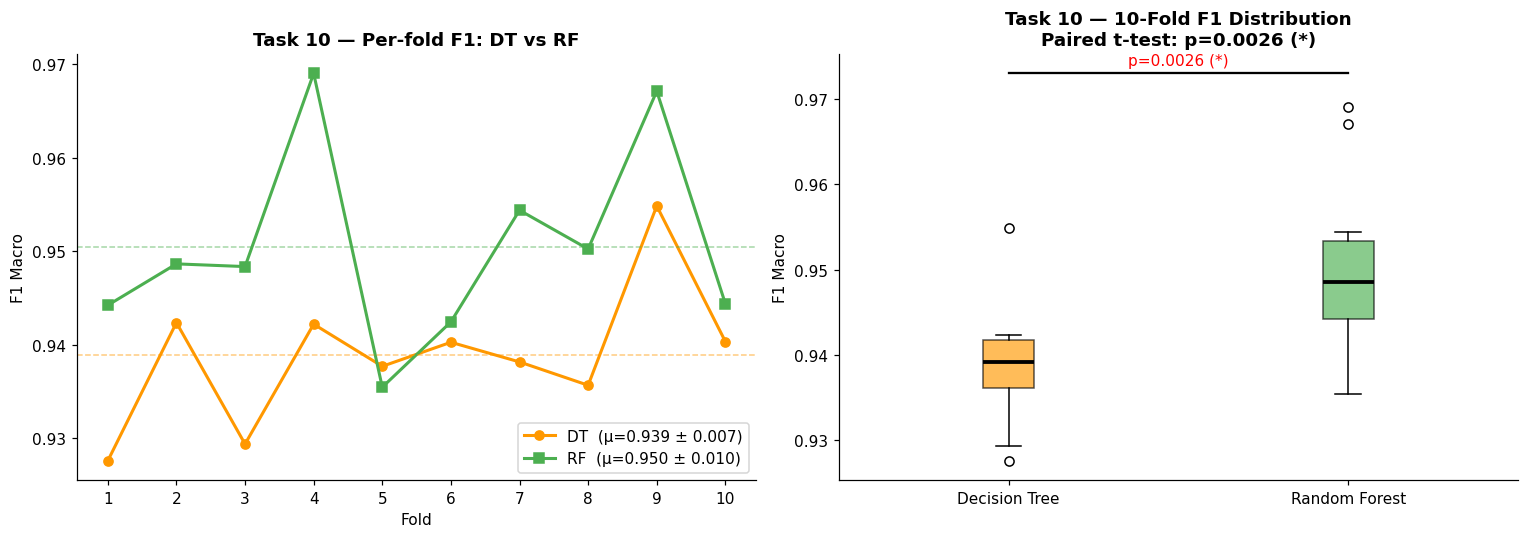


════════════════════════════════════════════════════════════
FINAL SUMMARY TABLE
════════════════════════════════════════════════════════════


,Subset-B F1,CV Mean F1,CV Std F1,CV Mean Acc
Model,,,,
Decision Tree,0.9413,0.9389,0.0072,0.9408
Random Forest,0.9571,0.9504,0.0100,0.9520


In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
folds = np.arange(1, 11)

axes[0].plot(folds, dt_f1s, "o-", color="#FF9800", lw=2, label=f"DT  (μ={dt_f1s.mean():.3f} ± {dt_f1s.std():.3f})")
axes[0].plot(folds, rf_f1s, "s-", color="#4CAF50", lw=2, label=f"RF  (μ={rf_f1s.mean():.3f} ± {rf_f1s.std():.3f})")
axes[0].axhline(dt_f1s.mean(), color="#FF9800", linestyle="--", lw=1, alpha=0.5)
axes[0].axhline(rf_f1s.mean(), color="#4CAF50", linestyle="--", lw=1, alpha=0.5)
axes[0].set_xlabel("Fold"); axes[0].set_ylabel("F1 Macro")
axes[0].set_title("Task 10 — Per-fold F1: DT vs RF", fontweight="bold")
axes[0].legend(); axes[0].set_xticks(folds)

bp = axes[1].boxplot([dt_f1s, rf_f1s], labels=["Decision Tree","Random Forest"],
                     patch_artist=True, medianprops=dict(color="k", lw=2.5))
for patch, col in zip(bp["boxes"], ["#FF9800","#4CAF50"]):
    patch.set_facecolor(col); patch.set_alpha(0.65)
sig_label = f"p={p_val:.4f} (*)" if p_val < 0.05 else f"p={p_val:.4f} (ns)"
axes[1].set_ylabel("F1 Macro")
axes[1].set_title(f"Task 10 — 10-Fold F1 Distribution\nPaired t-test: {sig_label}", fontweight="bold")
y_max = max(dt_f1s.max(), rf_f1s.max())
axes[1].plot([1, 2], [y_max+0.004, y_max+0.004], "k-", lw=1.5)
axes[1].text(1.5, y_max+0.005, sig_label, ha="center", fontsize=10, color="red")

plt.tight_layout(); plt.show()

# Summary table
summary = pd.DataFrame({
    "Model":        ["Decision Tree","Random Forest"],
    "Subset-B F1":  [round(f1_dt_test,4), round(f1_rf_test,4)],
    "CV Mean F1":   [round(dt_f1s.mean(),4), round(rf_f1s.mean(),4)],
    "CV Std  F1":   [round(dt_f1s.std(),4),  round(rf_f1s.std(),4)],
    "CV Mean Acc":  [round(dt_cv["test_accuracy"].mean(),4),
                     round(rf_cv["test_accuracy"].mean(),4)],
})
print("\n" + "═"*60)
print("FINAL SUMMARY TABLE")
print("═"*60)
display(summary.set_index("Model"))


### Task 10 Discussion

**10-fold cross-validation results:**

| Model | CV Mean F1 | CV Std F1 | Subset-B F1 |
|---|---|---|---|
| Decision Tree | 0.9389 | 0.0072 | 0.9413 |
| Random Forest | 0.9504 | 0.0100 | 0.9571 |

**Why cross-validation over a single run?**

A single train-test split is subject to high variance: depending on which instances fall in the test set (by chance), the measured F1 can fluctuate considerably. The 10-fold CV:
1. Uses all 4 999 instances for both training (9 folds) and testing (1 fold), producing a lower-variance estimate of generalisation performance.
2. Reports 10 F1 values, allowing computation of a confidence interval and statistical testing.
3. Detects performance instability (high std) that a single run would mask.
4. Provides a more credible estimate of the model's performance on truly unseen data.

**Comparison with Subset A→B results:**
The CV results (DT: 0.9389, RF: 0.9504) are consistent with the single-split results (0.9413 and 0.9571), providing **independent confirmation** that the models generalise well. The small discrepancy arises because the single split used 60% of data for training and 40% for testing, while 10-fold CV uses 90% for training and 10% for testing — slightly more training data per fold.

**Statistical significance (paired t-test):**

The paired t-test compares the 10 RF F1 values against the 10 DT F1 values on the *same folds*, controlling for fold-level variability. Result: **t = 4.13, p = 0.0026**.

Since p < 0.05 (and indeed p < 0.01), the RF's superior performance is **statistically significant**. This means the observed difference (Δ ≈ 0.012 F1) is unlikely to be due to random chance. The RF's ensemble mechanism consistently and reliably outperforms the single Decision Tree across all 10 folds.

**Model selection conclusion:**
The Random Forest is the superior model for ECG heartbeat classification in this context. Its ensemble architecture reduces variance, better exploits the PCA-transformed feature space, and produces statistically significantly higher macro-F1 scores across both evaluation strategies.
